In [66]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from lightgbm import LGBMClassifier

In [18]:
df = pd.read_parquet("all_features.parquet")

print(df.shape)
df.head()

(61410, 53)


,customer_id,customer_type,label,cash_value_ratio,emt_velocity_monthly_mean,income_transaction_gap_score,is_retired,is_unemployed,occupation_sector_id,spending_income_ratio,...,msb_net_retention_ratio,struct_total_near_n,struct_days_with_near,struct_max_near_in_day,struct_total_near_sum,tx_country_n,tx_province_n,tx_city_n,pct_tx_province_mismatch,pct_tx_city_mismatch
0,SYNID0100000167,IND,NaN,0.000000,0.000000,0.807090,0.0,0.0,2.0,0.000000,...,0.706175,0,0,0,0.0,0,0,0,1.000000,1.000000
1,SYNID0100000431,IND,NaN,0.183417,9.333333,NaN,0.0,0.0,18.0,NaN,...,-0.291106,0,0,0,0.0,1,7,21,1.000000,0.750000
2,SYNID0100000485,IND,0.0,0.037841,0.000000,1.460746,1.0,0.0,18.0,0.234281,...,0.328867,0,0,0,0.0,1,6,13,0.750000,0.975000
3,SYNID0100000539,IND,NaN,0.000000,3.500000,0.016742,1.0,0.0,18.0,0.863900,...,-0.968301,0,0,0,0.0,5,10,40,1.000000,0.673333
4,SYNID0100000932,IND,NaN,0.012255,1.000000,17.062930,1.0,0.0,18.0,1.579105,...,0.661526,0,0,0,0.0,2,12,40,0.598174,0.926941


In [19]:
print("Total rows:", len(df))

print("\nLabel counts:")
print(df["label"].value_counts(dropna=False))

print("\nLabeled rows:", df["label"].notna().sum())
print("Unlabeled rows:", df["label"].isna().sum())

Total rows: 61410

Label counts:
label
NaN    60410
0.0      990
1.0       10
Name: count, dtype: int64

Labeled rows: 1000
Unlabeled rows: 60410


In [20]:
###### data preperation ########
# Seperate labeled and unlabeled
df_labeled = df[df["label"].notna()].copy()
df_unlabeled = df[df["label"].isna()].copy()

In [21]:
# check missing value
import numpy as np

print("Any NaN in df?", df.isna().any().any())
print("NaN count total:", df.isna().sum().sum())

X = df.drop(columns=["label"])
X = X.select_dtypes(include=["number"])

print("X shape:", X.shape)
print("NaN count in X:", X.isna().sum().sum())

Any NaN in df? True
NaN count total: 303136
X shape: (61410, 50)
NaN count in X: 242726


In [23]:
# drop identifier and label
X = df.drop(columns=["customer_id", "label"])

# one-hot encode categorical variables
X = pd.get_dummies(X, columns=["customer_type", "occupation_sector_id"], drop_first=True)
X = X.select_dtypes(include=["number"])


In [24]:
# impute by median
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [30]:
###### PCA and Clustering #######
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

In [31]:
# clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=7, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df["cluster"] = clusters

In [37]:
# view cluster sizes
df["cluster"].value_counts()

,count
cluster,
6,21185
0,16203
2,14129
5,4420
3,2756
4,2621
1,96


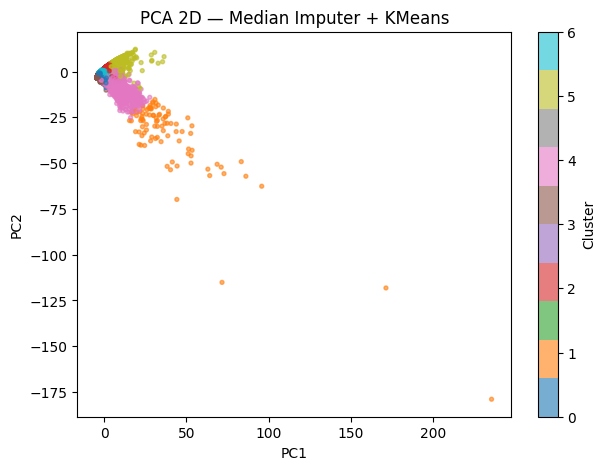

In [33]:
#### Visualization for PCA result #####
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled) # Use X_scaled for PCA

plt.figure(figsize=(7,5))
sc = plt.scatter(coords[:,0], coords[:,1], c=df["cluster"], cmap="tab10", alpha=0.6, s=8) # Use df["cluster"]
plt.title("PCA 2D — Median Imputer + KMeans")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.colorbar(sc, label="Cluster")
plt.show()

In [ ]:
# ouotput the clusters to csv
# df.to_csv("customer_clusters.csv", index=False)

In [53]:
####### Base-line model : Logistic Regression #######
# with lables
df_labeled = df.dropna(subset=["label"]).copy()

drop_cols = ["customer_id"]
X_all = df_labeled.drop(columns=drop_cols + ["label"], errors="ignore")

# cluster as catergory
X_all[cluster_col] = X_all[cluster_col].astype("category")

y = df_labeled["label"].astype(int)

In [54]:
X_all = X_all.dropna(axis=1, how="all")

#  numeric / categorical
cat_cols = X_all.select_dtypes(include=["object","category","bool"]).columns.tolist()
num_cols = [c for c in X_all.columns if c not in cat_cols]

# numeric -> median impute; categorical -> most_frequent + onehot
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

In [61]:
# Define Logistic Regression Model
model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['cash_value_ratio',
                                                   'emt_velocity_monthly_mean',
                                                   'income_transaction_gap_score',
                                                   'is_retired',
                                                   'is_unemployed',
                                                   'occupation_sector_id',
                                                   'spending_income_ratio',
                                                   'rapid_outflow_ratio_24h',
                                                   'mean_debit', 'median_debit',
                                                   'std_debi...
                                                   'iqr_velocity',
                                                   'mad_velocity',
                                                   'skew_velocity',
                                                   'late_night_txn_count',
                                                   'late_night_ratio',
                                                   'weekend_txn_count',
                                                   'activity_span_days', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['customer_type',
                                                   'cluster'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=5000))])

In [62]:
proba = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))


ROC-AUC: 0.6439393939393939
PR-AUC: 0.10719424460431655
Precision: 0.07142857142857142
Recall: 0.5
F1: 0.125


In [67]:
##### Baseline Model - lightgbm #####
def train_eval_lgbm(X, y, test_size=0.2, random_state=42, threshold=0.5):
    X = X.copy()
    y = pd.Series(y).astype(int)

    # 1) split first (no leakage)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # 2) LightGBM: object -> category (do AFTER split to be safe)
    for c in X_train.select_dtypes(include=["object"]).columns:
        X_train[c] = X_train[c].astype("category")
        X_test[c]  = X_test[c].astype("category")

    # 3) impute numeric (fit on train only)
    num_cols = X_train.select_dtypes(include=["number"]).columns
    if len(num_cols) > 0:
        imp = SimpleImputer(strategy="median")
        X_train[num_cols] = imp.fit_transform(X_train[num_cols])
        X_test[num_cols]  = imp.transform(X_test[num_cols])

    # 4) class imbalance weight
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    spw = (neg / max(pos, 1))

    model = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        scale_pos_weight=spw
    )

    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    metrics = {
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "pos_rate_test": float(y_test.mean()),
        "scale_pos_weight": float(spw)
    }
    return model, metrics

In [ ]:
model, metrics = train_eval_lgbm(X_all, y)
print(metrics)

[LightGBM] [Info] Number of positive: 8, number of negative: 792
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000747 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6378
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010000 -> initscore=-4.595120
[LightGBM] [Info] Start training from score -4.595120
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [68]:
##### Baseline Model - LightGBM #####
def train_eval_lgbm_fixed_split(X_train, X_test, y_train, y_test, threshold=0.5):

    X_train = X_train.copy()
    X_test = X_test.copy()
    y_train = pd.Series(y_train).astype(int)
    y_test = pd.Series(y_test).astype(int)

    # object -> category
    for c in X_train.select_dtypes(include=["object"]).columns:
        X_train[c] = X_train[c].astype("category")
        X_test[c]  = X_test[c].astype("category")

    # class imbalance weight
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    spw = neg / max(pos, 1)

    model = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        scale_pos_weight=spw
    )

    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    metrics = {
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "pos_rate_test": float(y_test.mean())
    }

    return model, metrics

In [69]:
model, metrics = train_eval_lgbm_fixed_split(X_train, X_test, y_train, y_test)
print(metrics)

# The model cannot find meaningful splits due to limited labeled data

[LightGBM] [Info] Number of positive: 8, number of negative: 792
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000599 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5914
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010000 -> initscore=-4.595120
[LightGBM] [Info] Start training from score -4.595120
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [40]:
results = []

for k in range(2, 11):

    cluster_labels = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    ).fit_predict(X_pca)

    sil = silhouette_score(X_pca, cluster_labels)

    fraud_std = (
        pd.DataFrame({
            "cluster": cluster_labels,
            "label": df["label"]
        })
        .groupby("cluster")["label"]
        .mean()
        .std()
    )

    results.append((k, sil, fraud_std))

results_df = (
    pd.DataFrame(results, columns=["k", "silhouette_score", "fraud_rate_std"])
    .sort_values("fraud_rate_std", ascending=False)
)

results_df

,k,silhouette_score,fraud_rate_std
3,5,0.151437,0.052802
4,6,0.114707,0.047102
7,9,0.105055,0.042721
8,10,0.107298,0.042721
5,7,0.102556,0.042714
2,4,0.146984,0.007637
6,8,0.101588,0.006100
1,3,0.267376,0.001979
0,2,0.819083,NaN
